Target joint positions: {'shoulder_pan_joint': 1.4648540427452668, 'shoulder_lift_joint': -1.9254054698865943, 'elbow_joint': 0.8793854211585046, 'wrist_1_joint': 2.4378353207192287, 'wrist_2_joint': 2.161134559592856, 'wrist_3_joint': -1.608932971556215, 'base_to_lik': 0.2594258109342944}


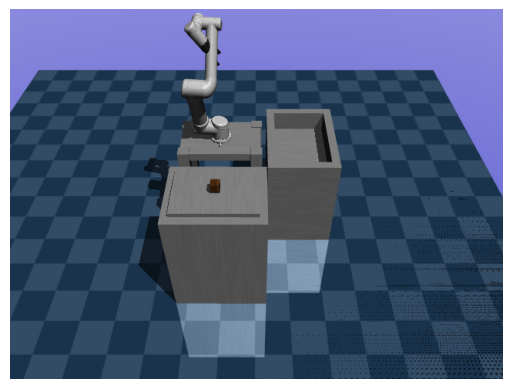

Warm xs: 3001
Positions dict: {'shoulder_pan_joint': 1.2680193316893478, 'shoulder_lift_joint': -1.6901750761564749, 'elbow_joint': 0.9875603883760171, 'wrist_1_joint': 0.41966816796740886, 'wrist_2_joint': 0.38223262919295764, 'wrist_3_joint': -0.7094686959023258, 'base_to_lik': -0.008658191055728931}


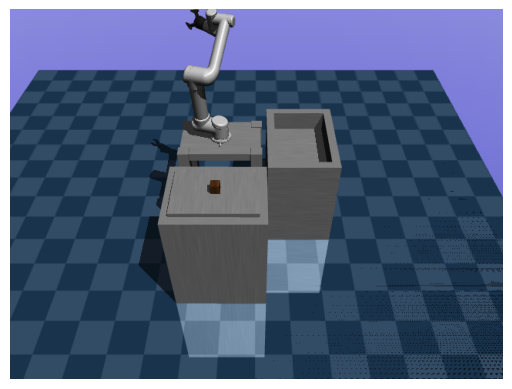

In [ ]:
from pathlib import Path
import mujoco
import numpy as np
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPDController import RobotPDController
import matplotlib.pyplot as plt

MODEL_PATH = Path.cwd().parent / "models" / "UR5gripper_2_finger_KKI.xml"
MujModel = RobotMujocoModel(MODEL_PATH)

controller = RobotPDController(MujModel, kp=50.0, kd=25.0)
# controller = RobotPDController(MujModel)

q0 = MujModel.actuated_joint_positions
v0 = np.zeros_like(MujModel.v_indices())
x0 = np.concatenate([list(q0.values()), list(v0)])

q_target = MujModel.random_actuated_q()
# print("Target joint positions:", q_target)
# q_target = {'shoulder_pan_joint': 0.876943014441486, 'shoulder_lift_joint': -1.444413665177651, 'elbow_joint': -0.005655999809186074, 'wrist_1_joint': 0.6457190588893957, 'wrist_2_joint': -3.0945858658471095, 'wrist_3_joint': 0.06757263577653694, 'base_to_lik': 0.5046540468473186}
v_target = np.zeros_like(MujModel.v_indices())
target = np.concatenate([list(q_target.values()), list(v_target)])
MujModel.joint_positions = q_target
MujModel.snapshot(plot=True)
MujModel.joint_positions = q0
# MujModel.snapshot(plot=True)

# print("Initial state (x0):", x0)
# print("Target state (x):", target)
warm_xs, warm_us = controller.compute_control(x0, target, 3000)
# print("Computed control:", warm_us)
# print("Computed states:", warm_xs)
print(f"Warm xs: {len(warm_xs)}")

    
for x in warm_xs[-1:]:
    # print("State:", x)
    # print("Joint positions:", x[:MujModel.q_indices().size])
    positions_dict = {name: float(x[idx]) for name, idx in zip(MujModel.actuated_joint_names, MujModel.q_indices())}
    print("Positions dict:", positions_dict)
    MujModel.joint_positions = positions_dict
    MujModel.snapshot(plot=True)


In [45]:
import time
import mujoco
import mujoco.viewer
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display

render_mode = "inline"  # choose: "inline" or "window"
# render_mode = "inline"  # choose: "inline" or "window"
MujModel.reset()  # reset to initial state (q0, v0)


if render_mode == "window":
    with mujoco.viewer.launch_passive(MujModel.model, MujModel.data) as viewer:
        for _ in range(len(warm_us)):
            u_cmd = warm_us[_]
            MujModel.data.ctrl[:] = u_cmd
            mujoco.mj_step(MujModel.model, MujModel.data)
            viewer.sync()
            time.sleep(MujModel.model.opt.timestep)
elif render_mode == "inline":
    renderer = mujoco.Renderer(MujModel.model, height=480, width=640)
    frames = []
    for _ in range(len(warm_us)):
        u_cmd = warm_us[_]
        MujModel.data.ctrl[:] = u_cmd
        mujoco.mj_step(MujModel.model, MujModel.data)
        renderer.update_scene(MujModel.data)
        frames.append(renderer.render().copy())
        time.sleep(MujModel.model.opt.timestep)

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.axis("off")
    im = ax.imshow(frames[0])

    def _update(frame_idx):
        im.set_data(frames[frame_idx])
        return (im,)

    ani = animation.FuncAnimation(fig, _update, frames=len(frames), interval=30, blit=True)
    plt.close(fig)
    display(HTML(ani.to_jshtml()))